# T1 mapping from **undersampled** IR data — BART LLR + ANTs + PSIR

Same structure, conventions and analysis as `T1map_fully_sampled_V1.ipynb`,
with the two things you asked for put back:

* **Joint locally-low-rank reconstruction** across the four inversion times
  (`pics -R L:7:7:lambda`), because a 4x undersampled adjoint NUFFT will alias.
* **Coil sensitivities from the separate T2 scan.**

Everything downstream of the reconstruction — echo registration, PSIR polarity
restoration, the closed-form T1 grid fit, export — is unchanged from the fully
sampled notebook.

### The one thing done differently from your V11 notebook

V11 reconstructed the T2 calibration data with `nlinv -x 72:88:40`, i.e. onto
the *IR* grid, while `rrdfconvert_fse` scales the trajectory by the *T2's own*
matrix. From your cell 89, the T2 is natively `170 x 138 x 40` at
1.294 x 1.304 x 5 mm — a 220 x 180 mm FOV — against the IR's 72 x 88 x 40 at
2.5 mm, a 180 x 220 mm FOV. Reconstructing one onto the other's grid stretches
the maps by roughly 22% in one axis and compresses them 18% in the other, and
the T2 readout trajectory (+/-85) overruns the 72-point grid's Nyquist limit
(+/-36) so its outer k-space folds during gridding.

So here the T2 is reconstructed **at its own native grid**, and the resulting
maps are resampled into the IR frame using the physical geometry recorded in
each scan's `info.json`. Section 6 prints both geometries and draws an overlay
so you can see whether the two actually line up.

`SENS_SOURCE` lets you switch between three options and compare them directly:

| value | behaviour |
|---|---|
| `'t2_native'` | T2 reconstructed at its own grid, resampled to the IR frame *(default)* |
| `'t2_legacy'` | exactly what V11 did — `nlinv -x {RESO}` straight onto the IR grid |
| `'ir'` | self-calibrate on the longest-TI IR volume, no T2 scan involved |

If `'t2_native'` and `'t2_legacy'` give you the same T1 numbers, my concern was
overstated and you can ignore it. If they don't, you'll want to know.

### Also carried over from the earlier review

* The V11 filename regex `rf"{date}_(\d+)\.h5$"` did not match
  `T2_axi_rrdf_20260706_gummy_193104.h5`, so that T2 was never converted and
  cell 12 silently fell through to a hardcoded `..._190048_...` from ~35 min
  earlier. The globbing here is loose and prints what it resolved.
* `x_coord` uses `arange(nread) - nread//2` so dk = 1 and DC sits on a sample.
* Zero-padding across TIs with differing spoke counts now carries a `-p`
  weight file, so padded samples don't act as fake data at k = 0.
* Echo registration is estimated once at the reference TI, not at every TI
  including the near-null one.
* Shared display windowing; `NaN` rather than `0` for unfitted voxels.

## 1. Environment

In [30]:
import os
import re
import sys
import json
from pathlib import Path

import numpy as np
import h5py
import matplotlib.pyplot as plt

BART_PATH = os.environ.get('BART_TOOLBOX_PATH', '/Users/jackewins/bart/')
os.environ['BART_TOOLBOX_PATH'] = BART_PATH
sys.path.append(os.path.join(BART_PATH, 'python'))
from bart import bart, cfl

import ants
import nibabel as nib
from scipy.optimize import curve_fit

%matplotlib inline
plt.rcParams['figure.facecolor'] = 'white'
print('BART toolbox:', BART_PATH)

BART toolbox: /Users/jackewins/bart/


## 2. Configuration

In [31]:
# ---- study -----------------------------------------------------------------
patient   = 'Gummy_US4'
date      = '20260706'
TI        = ['025', '150', '400', '800']      # ms, ASCENDING order
TI_ms     = np.array([int(t) for t in TI], dtype=float)
TR_BASE_S = 1.200                             # s.  TR_true = TR_BASE_S + TI
RES_MM    = (2.5, 2.5, 5.0)                   # read, phase, slice
MATRIX    = (72, 88, 40)
RESO      = ':'.join(str(m) for m in MATRIX)

# ---- paths -----------------------------------------------------------------
DATA_DIR = Path('./T1_map_raw/Phantom/Gummy')
CFL_DIR  = DATA_DIR / 'CFL'
T2_DIR   = Path('./T1_map_raw/T2_sens')
T2_CFL   = T2_DIR / 'CFL'
OUT_DIR  = Path('./T1_map_data') / date

US_VER  = 'US_4'
H5_GLOB = 'T1_UBC_IR{ti}*{us}*{date}*.h5'     # loose on purpose
T2_GLOB = 'fse_fast_t2_rrdf_{date}_*.h5'

# ---- sensitivity maps ------------------------------------------------------
SENS_SOURCE  = 't2_native'   # 't2_native' | 't2_legacy' | 'ir'
SENS_REF_TI  = '800'         # used by 'ir', and as the registration target
T2_TRANSPOSE = 'auto'        # 'auto' | None | a tuple e.g. (1, 0, 2)
T2_REGISTER  = False         # rigid-refine T2 -> IR (leave off for a static phantom)
NLINV_CMD    = 'nlinv -m 2 -d 3 -a 30 -b 20 -i 12'   # your optimised ENLIVE values

# ---- LLR reconstruction ----------------------------------------------------
FOVSHIFT    = '0.:0.0:0.05'  # scanner-specific; None to disable
LLR_LAMBDA  = 0.005
LLR_BLK     = 4
LLR_ITER    = 40            # V11 used 20; see the note in section 8
PHASE_REF_TI = '800'
REG_PER_TI   = False

# ---- fitting ---------------------------------------------------------------
T1_RANGE_S = (0.02, 5.0)
T1_NGRID   = 2000
MASK_FRAC  = 0.08
REFINE_FIT = False

## 3. rrdf -> BART converter

Identical to the fully sampled notebook. The one change from V11 is `x_coord`:
`linspace(-n/2, n/2, n)` includes both endpoints, giving dk = n/(n-1) = 1.0141
at n = 72 and leaving no sample at k = 0 (nearest is -0.507). That is a 1.4%
readout FOV compression plus a half-sample offset, i.e. a half-pixel shift and
a linear phase ramp.

In [32]:
def rrdfconvert_fse(filename, bartname, fovshift=FOVSHIFT):
    '''Convert a Hyperfine V11 rrdf .h5 into BART cfl data + trajectory.'''
    with h5py.File(filename, 'r') as f:
        mat        = f['/sequence/matrix_size'][()]
        ksp        = f['data/data_matrix'][()]
        traj       = f['data/kspace_coordinate_pe'][()]
        fov        = f['/sequence/fov'][()]
        resolution = f['/sequence/resolution'][()]
        geom       = f['/sequence/acquisition_geometry'][()]

    nread, p1, p2 = int(mat[0]), int(mat[1]), int(mat[2])

    # ---- FIXED vs V11 ------------------------------------------------------
    x_coord = np.arange(nread) - nread // 2          # dk = 1, DC on-grid
    # ------------------------------------------------------------------------

    newtraj = np.swapaxes(traj, 1, 2)
    traj3d  = np.zeros((3, traj.shape[2], traj.shape[1], nread))

    traj3d[0, ...] = np.broadcast_to(
        x_coord, (ksp.shape[2], ksp.shape[3], ksp.shape[1]))
    traj3d[1, ...] = np.transpose(np.broadcast_to(
        p1 * newtraj[:1, ...],
        (ksp.shape[1], 1, ksp.shape[2], ksp.shape[3])), (1, 2, 3, 0))
    traj3d[2, ...] = np.transpose(np.broadcast_to(
        p2 * newtraj[1:, ...],
        (ksp.shape[1], 1, ksp.shape[2], ksp.shape[3])), (1, 2, 3, 0))

    barttraj = np.moveaxis(traj3d[:, :, :, :, None, None, None],
                           [0, 3, 2, 4, 5, 1, 6], [0, 1, 2, 3, 4, 5, 6])
    bartksp  = np.moveaxis(ksp[:, :, :, :, None, None, None],
                           [4, 1, 3, 0, 5, 2, 6], [0, 1, 2, 3, 4, 5, 6])

    if fovshift:
        bartksp = bart(1, f'fovshift -s {fovshift} -t', barttraj, bartksp)

    cfl.writecfl(f'{bartname}_data', bartksp)
    cfl.writecfl(f'{bartname}_traj', barttraj)

    info = {'fov':    [float(x) for x in fov],
            'matrix': [int(x) for x in mat],
            'res':    [float(x) for x in resolution],
            'geom':   str(geom)[2:-1]}
    with open(f'{bartname}_info.json', 'w') as fj:
        json.dump(info, fj, indent=2)
    return info


def convert_one(h5_path, out_stem):
    '''Convert if needed, otherwise load the cached info.json.'''
    if Path(f'{out_stem}.cfl').exists():
        return json.load(open(f'{out_stem}_info.json')), 'cached'
    return rrdfconvert_fse(h5_path, out_stem), 'converted'

## 4. Convert the IR series and the T2 calibration scan

Both mappings are printed. Read them — a silent mismatch here is invisible
until it shows up as one inversion time looking wrong.

In [33]:
CFL_DIR.mkdir(parents=True, exist_ok=True)
T2_CFL.mkdir(parents=True, exist_ok=True)

scan = {}
for ti in TI:
    pat = H5_GLOB.format(ti=ti, us=US_VER, date=date)
    matches = sorted(DATA_DIR.glob(pat))
    if not matches:
        raise FileNotFoundError(
            f"No .h5 matched TI={ti} with '{pat}' in {DATA_DIR}\n"
            f"Present: {[p.name for p in sorted(DATA_DIR.glob('*.h5'))]}")
    if len(matches) > 1:
        print(f"  !! {len(matches)} files match TI={ti}: "
              f"{[m.name for m in matches]} -- using the last")
    h5 = matches[-1]
    m = re.search(r'(\d{6})\.h5$', h5.name)
    stem = CFL_DIR / f'IR{ti}_{date}_{m.group(1) if m else h5.stem}'
    info, state = convert_one(h5, str(stem))
    scan[ti] = {'h5': h5.name, 'stem': stem, 'info': info}
    print(f"TI={ti:>4} ms  [{state:9s}]  {h5.name}")
    print(f"              matrix={info['matrix']}  "
          f"fov={[round(v, 1) for v in info['fov']]}")

# ---- T2 calibration scan ---------------------------------------------------
t2_matches = sorted(T2_DIR.glob(T2_GLOB.format(date=date)))
if not t2_matches:
    raise FileNotFoundError(
        f"No T2 .h5 matched '{T2_GLOB.format(date=date)}' in {T2_DIR}\n"
        f"Present: {[p.name for p in sorted(T2_DIR.glob('*.h5'))]}")
if len(t2_matches) > 1:
    print(f"\n  !! {len(t2_matches)} T2 files: {[m.name for m in t2_matches]}"
          f" -- using the last (closest in time to the IR series)")
t2_h5 = t2_matches[-1]
m = re.search(r'(\d{6})\.h5$', t2_h5.name)
t2_stem = T2_CFL / f'T2_sens_map_{date}_{m.group(1) if m else t2_h5.stem}'
t2_info, state = convert_one(t2_h5, str(t2_stem))
print(f"\nT2 sens    [{state:9s}]  {t2_h5.name}")
print(f"              matrix={t2_info['matrix']}  "
      f"fov={[round(v, 1) for v in t2_info['fov']]}")

TI= 025 ms  [converted]  T1_UBC_IR025_TR_1200_US_4.user_rrdf_20260706_193145.h5
              matrix=[72, 88, 40]  fov=[0.2, 0.2, 0.2]
TI= 150 ms  [converted]  T1_UBC_IR150_TR_1200_US_4.user_rrdf_20260706_193504.h5
              matrix=[72, 88, 40]  fov=[0.2, 0.2, 0.2]
TI= 400 ms  [converted]  T1_UBC_IR400_TR_1200_US_4.user_rrdf_20260706_193842.h5
              matrix=[72, 88, 40]  fov=[0.2, 0.2, 0.2]
TI= 800 ms  [converted]  T1_UBC_IR800_TR_1200_US_4.user_rrdf_20260706_194257.h5
              matrix=[72, 88, 40]  fov=[0.2, 0.2, 0.2]

T2 sens    [converted]  fse_fast_t2_rrdf_20260706_193035.h5
              matrix=[138, 112, 40]  fov=[0.2, 0.2, 0.2]


## 5. Load and split echoes

`R` well above 1 is expected here — that is the whole reason for the LLR step.

In [34]:
k_data, k_traj = {}, {}
for ti in TI:
    k_data[ti] = cfl.readcfl(f'{scan[ti]["stem"]}_data')
    k_traj[ti] = cfl.readcfl(f'{scan[ti]["stem"]}_traj')

t2_data = cfl.readcfl(f'{t2_stem}_data')
t2_traj = cfl.readcfl(f'{t2_stem}_traj')

ECHOES = ('even', 'odd')
kd = {e: {ti: k_data[ti][:, :, :, :, :, i] for ti in TI} for i, e in enumerate(ECHOES)}
kt = {e: {ti: k_traj[ti][:, :, :, :, :, i] for ti in TI} for i, e in enumerate(ECHOES)}
t2d = {e: t2_data[:, :, :, :, :, i] for i, e in enumerate(ECHOES)}
t2t = {e: t2_traj[:, :, :, :, :, i] for i, e in enumerate(ECHOES)}

nx, ny, nz = MATRIX
print(f"IR recon grid {nx} x {ny} x {nz}  ->  {ny * nz} PE positions for R = 1\n")
for ti in TI:
    t, d = kt['even'][ti], kd['even'][ti]
    print(f"TI={ti:>4}  data{d.shape}  {t.shape[2]:>6} PE   "
          f"R = {ny * nz / t.shape[2]:5.2f}")
print(f"\nT2      data{t2d['even'].shape}  {t2t['even'].shape[2]:>6} PE")

IR recon grid 72 x 88 x 40  ->  3520 PE positions for R = 1

TI= 025  data(1, 72, 2304, 8, 1)    2304 PE   R =  1.53
TI= 150  data(1, 72, 2304, 8, 1)    2304 PE   R =  1.53
TI= 400  data(1, 72, 2304, 8, 1)    2304 PE   R =  1.53
TI= 800  data(1, 72, 2304, 8, 1)    2304 PE   R =  1.53

T2      data(1, 138, 3196, 8, 1)    3196 PE


## 6. Coil sensitivities from the T2 scan

The T2 is reconstructed at **its own** matrix, so the trajectory scaling in
`rrdfconvert_fse` (which uses that scan's `matrix_size`) is self-consistent and
no k-space folds. The maps are then moved into the IR frame as a physical-space
resampling, with both grids centred on isocentre.

`T2_TRANSPOSE = 'auto'` compares the two FOV vectors and applies an in-plane
axis swap if the T2's readout FOV matches the IR's *phase* FOV rather than its
readout FOV. Check the printed geometry and the overlay below — if the outline
of the T2 object doesn't sit on top of the IR object, override `T2_TRANSPOSE`
manually.

In [35]:
ir_fov     = np.array(scan[SENS_REF_TI]['info']['fov'], float)
ir_matrix  = np.array(scan[SENS_REF_TI]['info']['matrix'], int)
t2_fov     = np.array(t2_info['fov'], float)
t2_matrix  = np.array(t2_info['matrix'], int)
ir_spacing = ir_fov / ir_matrix
t2_spacing = t2_fov / t2_matrix

print(f"IR : matrix {tuple(ir_matrix)}  fov {np.round(ir_fov, 1)} mm  "
      f"-> spacing {np.round(ir_spacing, 3)} mm")
print(f"T2 : matrix {tuple(t2_matrix)}  fov {np.round(t2_fov, 1)} mm  "
      f"-> spacing {np.round(t2_spacing, 3)} mm")
print(f"\nconfig RES_MM = {RES_MM}, MATRIX = {MATRIX}")
if not np.allclose(ir_spacing, RES_MM, atol=0.05):
    print("  !! header spacing disagrees with RES_MM -- trust the header")

if T2_TRANSPOSE == 'auto':
    swapped = abs(t2_fov[0] - ir_fov[1]) + abs(t2_fov[1] - ir_fov[0])
    direct  = abs(t2_fov[0] - ir_fov[0]) + abs(t2_fov[1] - ir_fov[1])
    t2_perm = (1, 0, 2) if swapped < direct else None
    print(f"\nauto transpose: direct mismatch {direct:.1f} mm, "
          f"swapped {swapped:.1f} mm  ->  {t2_perm}")
else:
    t2_perm = T2_TRANSPOSE
    print(f"\nT2 transpose (manual): {t2_perm}")

IR : matrix (np.int64(72), np.int64(88), np.int64(40))  fov [0.2 0.2 0.2] mm  -> spacing [0.002 0.002 0.005] mm
T2 : matrix (np.int64(138), np.int64(112), np.int64(40))  fov [0.2 0.2 0.2] mm  -> spacing [0.002 0.002 0.005] mm

config RES_MM = (2.5, 2.5, 5.0), MATRIX = (72, 88, 40)
  !! header spacing disagrees with RES_MM -- trust the header

auto transpose: direct mismatch 0.1 mm, swapped 0.0 mm  ->  (1, 0, 2)


In [36]:
T2_RESO = ':'.join(str(int(m)) for m in t2_matrix)


def centred(vol, spacing):
    '''Wrap a 3D volume as an ANTsImage centred on isocentre.'''
    img = ants.from_numpy(np.ascontiguousarray(vol, dtype=np.float32),
                          spacing=tuple(float(s) for s in spacing))
    img.set_origin(tuple(float(-(n - 1) * s / 2.0)
                         for n, s in zip(vol.shape, spacing)))
    return img


IR_REF_GRID = centred(np.zeros(MATRIX, np.float32), ir_spacing)


def to_ir_grid(vol, spacing, xfm=None):
    '''Resample one 3D real volume from its own physical grid onto the IR grid.'''
    src = centred(vol, spacing)
    if xfm:
        return ants.apply_transforms(fixed=IR_REF_GRID, moving=src,
                                     transformlist=xfm,
                                     interpolator='linear').numpy()
    return ants.resample_image_to_target(src, IR_REF_GRID,
                                         interp_type='linear').numpy()


def unit_rss(s):
    rss = np.sqrt(np.sum(np.abs(s) ** 2, axis=3, keepdims=True))
    rss = np.where(rss > 1e-9 * rss.max(), rss, np.inf)
    return (s / rss).astype(np.complex64)


sens, t2_ref_img = {}, {}

for e in ECHOES:
    if SENS_SOURCE == 'ir':
        print(f'[{e}] ENLIVE on IR TI={SENS_REF_TI} ms, grid {RESO}')
        _, s = bart(2, f'{NLINV_CMD} -x {RESO} -t', kt[e][SENS_REF_TI], kd[e][SENS_REF_TI])
        s = np.squeeze(s)
        s = s[..., 0] if s.ndim == 5 else s

    elif SENS_SOURCE == 't2_legacy':
        print(f'[{e}] ENLIVE on T2 straight onto the IR grid {RESO}  (V11 behaviour)')
        _, s = bart(2, f'{NLINV_CMD} -x {RESO} -t', t2t[e], t2d[e])
        s = np.squeeze(s)
        s = s[..., 0] if s.ndim == 5 else s

    elif SENS_SOURCE == 't2_native':
        print(f'[{e}] ENLIVE on T2 at its native grid {T2_RESO}, then resample')
        im, s = bart(2, f'{NLINV_CMD} -x {T2_RESO} -t', t2t[e], t2d[e])
        im, s = np.squeeze(im), np.squeeze(s)
        s = s[..., 0] if s.ndim == 5 else s
        if im.ndim == 4:
            im = im[..., 0]

        if t2_perm is not None:
            s  = np.transpose(s, t2_perm + (3,))
            im = np.transpose(im, t2_perm)
        sp = t2_spacing[list(t2_perm)] if t2_perm is not None else t2_spacing

        xfm = None
        if T2_REGISTER:
            ir_mag = np.abs(np.squeeze(bart(
                1, f'nufft -t -a -d {RESO}', kt[e][SENS_REF_TI], kd[e][SENS_REF_TI])))
            ir_mag = np.sqrt((ir_mag ** 2).sum(-1))
            reg = ants.registration(centred(ir_mag / ir_mag.max(), ir_spacing),
                                    centred(np.abs(im) / np.abs(im).max(), sp),
                                    type_of_transform='Rigid', aff_metric='mattes')
            xfm = reg['fwdtransforms']
            print('    rigid refine:', xfm)

        s = np.stack([to_ir_grid(np.real(s[..., c]), sp, xfm)
                      + 1j * to_ir_grid(np.imag(s[..., c]), sp, xfm)
                      for c in range(s.shape[3])], axis=-1)
        t2_ref_img[e] = to_ir_grid(np.abs(im), sp, xfm)
    else:
        raise ValueError(SENS_SOURCE)

    sens[e] = unit_rss(s)
    print('   ->', sens[e].shape)

[even] ENLIVE on T2 at its native grid 138:112:40, then resample
ksp : [  1 138 3196   8   1   1   1   1   1   1   1   1   1   1   1   1 ]
cim : [138 112  40   8   1   1   1   1   1   1   1   1   1   1   1   1 ]
traj: [  3 138 3196   1   1   1   1   1   1   1   1   1   1   1   1   1 ]
wgh : [  1 138 3196   1   1   1   1   1   1   1   1   1   1   1   1   1 ]
NUFFT: Toeplitz mode

Model created (non Cartesian, nufft-based):
kspace:     [  1 138 3196   8   1   1   1   1   1   1   1   1   1   1   1   1 ]
images:     [138 112  40   1   2   1   1   1   1   1   1   1   1   1   1   1 ]
coils:      [138 112  40   8   2   1   1   1   1   1   1   1   1   1   1   1 ]
trajectory: [  3 138 3196   1   1   1   1   1   1   1   1   1   1   1   1   1 ]
pattern:    [  1 138 3196   1   1   1   1   1   1   1   1   1   1   1   1   1 ]
coilimg:    [138 112  40   8   1   1   1   1   1   1   1   1   1   1   1   1 ]

NUFFT: Toeplitz mode
ksp : [  1 138 3196   1   1   1   1   1   1   1   1   1   1   1   1   1   1

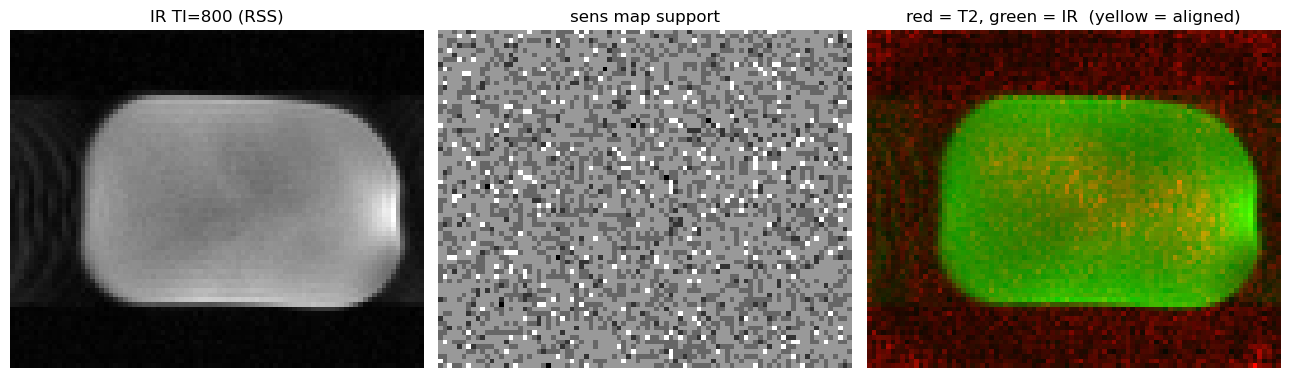

In [37]:
# QC 1: do the T2-derived maps actually sit on top of the IR object?
z = MATRIX[2] // 2
ir_mag = np.abs(np.squeeze(bart(1, f'nufft -t -a -d {RESO}',
                                kt['even'][SENS_REF_TI], kd['even'][SENS_REF_TI])))
ir_mag = np.sqrt((ir_mag ** 2).sum(-1))

fig, ax = plt.subplots(1, 3, figsize=(13, 4.4))
ax[0].imshow(ir_mag[:, :, z], cmap='gray'); ax[0].set_title(f'IR TI={SENS_REF_TI} (RSS)')
support = np.sqrt(np.sum(np.abs(sens['even'][:, :, z]) ** 2, axis=-1))
ax[1].imshow(support, cmap='gray'); ax[1].set_title('sens map support')

rgb = np.zeros(ir_mag[:, :, z].shape + (3,))
rgb[..., 1] = ir_mag[:, :, z] / max(ir_mag[:, :, z].max(), 1e-9)
if 'even' in t2_ref_img:
    t2v = t2_ref_img['even'][:, :, z]
    rgb[..., 0] = t2v / max(t2v.max(), 1e-9)
    ax[2].set_title('red = T2, green = IR  (yellow = aligned)')
else:
    ax[2].set_title('T2 reference image not available for this SENS_SOURCE')
ax[2].imshow(np.clip(rgb, 0, 1))
for a in ax:
    a.axis('off')
plt.tight_layout(); plt.show()

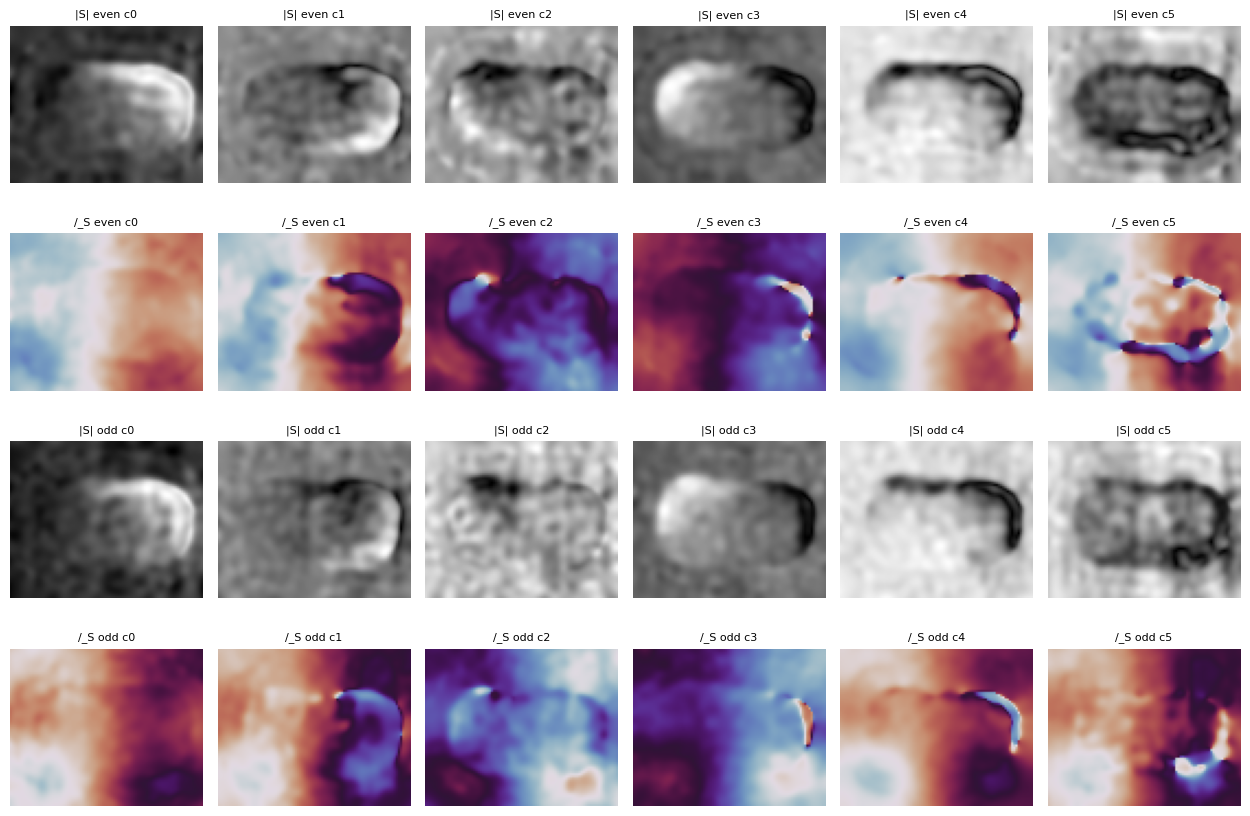

In [38]:
# QC 2: magnitude and phase of a few coils. Phase should be smooth and slowly
# varying; abrupt structure means the maps are fighting the data.
z = MATRIX[2] // 2
ncoil = min(6, sens['even'].shape[3])
fig, axes = plt.subplots(4, ncoil, figsize=(2.1 * ncoil, 8.6))
for r, e in enumerate(ECHOES):
    for c in range(ncoil):
        axes[2 * r, c].imshow(np.abs(sens[e][:, :, z, c]), cmap='gray')
        axes[2 * r, c].set_title(f'|S| {e} c{c}', fontsize=8)
        axes[2 * r + 1, c].imshow(np.angle(sens[e][:, :, z, c]),
                                  cmap='twilight', vmin=-np.pi, vmax=np.pi)
        axes[2 * r + 1, c].set_title(f'/_S {e} c{c}', fontsize=8)
for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout(); plt.show()

## 7. Stack the inversion times for the joint reconstruction

The four TIs go into BART's `TE` dimension (dim 5) so `pics` reconstructs them
in one call, sharing one data scaling — which is what keeps the amplitudes
comparable across TI and therefore keeps the T1 fit meaningful.

When the TIs have unequal spoke counts, V11's `pad_to_max_shape` zero-padded
the **trajectory** as well as the data, which places fake samples at exactly
k = (0,0,0) — a hard constraint pushing the image mean toward zero, applied
unevenly across TIs. Here the padded samples get zero weight through a `-p`
file instead. If all four TIs are the same length nothing is padded and no
pattern is passed.

In [39]:
def to6(a):
    return a.reshape(a.shape + (1,) * (6 - a.ndim))


def stack_tis(traj_d, data_d):
    trajs = [traj_d[ti] for ti in TI]
    datas = [data_d[ti] for ti in TI]
    tmax = np.max([t.shape for t in trajs], axis=0)
    dmax = np.max([d.shape for d in datas], axis=0)
    padding = any(tuple(t.shape) != tuple(tmax) for t in trajs)

    T, D, P = [], [], []
    for t, d in zip(trajs, datas):
        T.append(np.pad(t, [(0, a - b) for a, b in zip(tmax, t.shape)]))
        D.append(np.pad(d, [(0, a - b) for a, b in zip(dmax, d.shape)]))
        p = np.zeros((1, dmax[1], dmax[2], 1, 1), np.complex64)
        p[0, :d.shape[1], :d.shape[2], 0, 0] = 1.0
        P.append(p)

    T = np.concatenate([to6(x) for x in T], axis=5)
    D = np.concatenate([to6(x) for x in D], axis=5)
    P = np.concatenate([to6(x) for x in P], axis=5) if padding else None
    return T, D, P


stack = {}
for e in ECHOES:
    T, D, P = stack_tis(kt[e], kd[e])
    stack[e] = (T, D, P)
    print(f'{e:4s}  traj{T.shape}  data{D.shape}  '
          f'pattern={"none (equal spoke counts)" if P is None else P.shape}')

even  traj(3, 72, 2304, 1, 1, 4)  data(1, 72, 2304, 8, 1, 4)  pattern=none (equal spoke counts)
odd   traj(3, 72, 2304, 1, 1, 4)  data(1, 72, 2304, 8, 1, 4)  pattern=none (equal spoke counts)


## 8. Joint LLR reconstruction

`-R L:7:7:lambda -b 4` blocks the three spatial dimensions into 4x4x4 cubes and
soft-thresholds the singular values of each block's *voxel x TI* matrix.
`-N` makes the blocks fully overlapping, `-U` puts the NUFFT in low-memory mode.

`LLR_ITER` defaults to 100 rather than V11's 20. FISTA at 20 iterations is not
converged, and the unconverged residual is a much larger *fraction* of the true
signal at the inversion time closest to the null — part of why the 150 ms frame
looked strange. Expect a few minutes per echo. Drop it back to 20 if you are
only sanity-checking.

In [40]:
llr_cmd = (f'pics -e -S -N -R L:7:7:{LLR_LAMBDA} '
           f'-i {LLR_ITER} -b {LLR_BLK} -U -t')
print(llr_cmd, '\n')

img = {e: {} for e in ECHOES}
for e in ECHOES:
    T, D, P = stack[e]
    args = [T, D, sens[e][..., None]]
    cmd = llr_cmd if P is None else llr_cmd.replace('pics ', 'pics -p ')
    if P is not None:
        args = [P] + args        # -p pattern comes first in the argument list
    r = np.squeeze(bart(1, cmd, *args))          # (X, Y, Z, nTI)
    for j, ti in enumerate(TI):
        img[e][ti] = r[..., j]
    print(f'{e:4s} done  {r.shape}')

print()
for e in ECHOES:
    for ti in TI:
        print(f'{e:4s} TI={ti:>4}  max|I| = {np.abs(img[e][ti]).max():.4g}')

pics -e -S -N -R L:7:7:0.005 -i 40 -b 4 -U -t 

WARN: Turning off random shifts
Fully overlapping LLR blocks
[  1  72 2304   8   1   4   1   1   1   1   1   1   1   1   1   1 ]
[ 72  88  40   8   1   4   1   1   1   1   1   1   1   1   1   1 ]
lowrank regularization: 0.005000
Regularization terms: 1, Supporting variables: 0
FISTA
Total Time: 49.639640
even done  (72, 88, 40, 4)
WARN: Turning off random shifts
Fully overlapping LLR blocks
[  1  72 2304   8   1   4   1   1   1   1   1   1   1   1   1   1 ]
[ 72  88  40   8   1   4   1   1   1   1   1   1   1   1   1   1 ]
lowrank regularization: 0.005000
Regularization terms: 1, Supporting variables: 0
FISTA
Total Time: 49.148966
odd  done  (72, 88, 40, 4)

even TI= 025  max|I| = 19.68
even TI= 150  max|I| = 3.639
even TI= 400  max|I| = 21.81
even TI= 800  max|I| = 28.96
odd  TI= 025  max|I| = 20.7
odd  TI= 150  max|I| = 2.544
odd  TI= 400  max|I| = 21.44
odd  TI= 800  max|I| = 29.47


Those maxima come from a single `pics` call per echo, so they share one data
scaling and are directly comparable. The near-null TI should be a small
fraction of the longest TI.

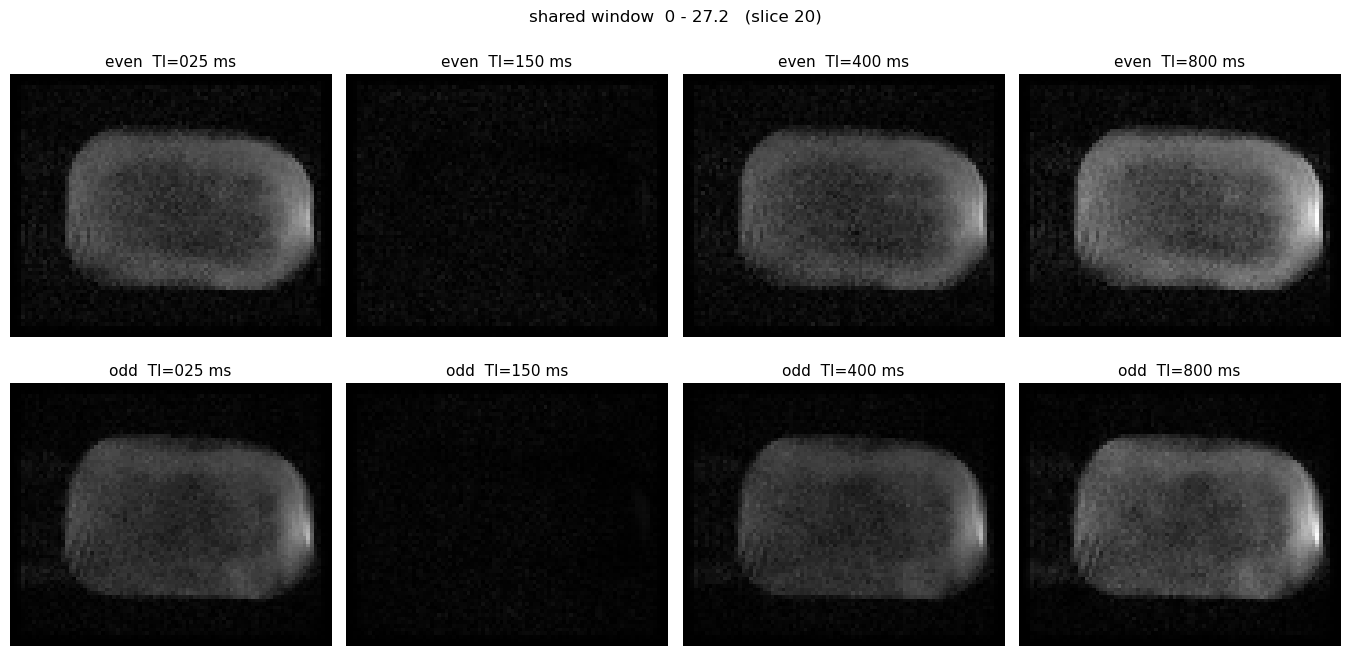

In [41]:
# Shared window across all TIs.
z = MATRIX[2] // 2
vmax = np.abs(img['even'][TI[-1]][:, :, z]).max()

fig, axes = plt.subplots(2, len(TI), figsize=(3.4 * len(TI), 7))
for r, e in enumerate(ECHOES):
    for c, ti in enumerate(TI):
        axes[r, c].imshow(np.abs(img[e][ti][:, :, z]),
                          cmap='gray', vmin=0, vmax=vmax)
        axes[r, c].set_title(f'{e}  TI={ti} ms', fontsize=11)
        axes[r, c].axis('off')
plt.suptitle(f'shared window  0 - {vmax:.3g}   (slice {z})')
plt.tight_layout(); plt.show()

## 9. [Diagnostic] Does the regulariser eat your small inserts?

Optional, and slow — one full reconstruction per lambda. Run it on the even
echo only and look at the **line profile**, not the images: a small insert that
LLR has absorbed into the surrounding mimic disappears from the profile long
before the image looks visibly over-smoothed.

Set `PROFILE_ROW` and `PROFILE_SLICE` to cut through the inserts you care
about. The fully sampled reconstruction is the ground truth to compare against.

In [42]:
RUN_SWEEP     = False
SWEEP_LAMBDAS = [0.001, 0.0025, 0.005, 0.0075]
SWEEP_TI      = '800'
PROFILE_SLICE = MATRIX[2] // 2
PROFILE_ROW   = MATRIX[0] // 2

if RUN_SWEEP:
    T, D, P = stack['even']
    j = TI.index(SWEEP_TI)
    sweep = {}
    for lam in SWEEP_LAMBDAS:
        cmd = (f'pics -e -S -N -R L:7:7:{lam} '
               f'-i {LLR_ITER} -b {LLR_BLK} -U -t')
        args = [T, D, sens['even'][..., None]]
        if P is not None:
            cmd = cmd.replace('pics ', 'pics -p '); args = [P] + args
        sweep[lam] = np.abs(np.squeeze(bart(1, cmd, *args))[..., j])
        print(f'lambda = {lam}: done')

    ref = sweep[min(SWEEP_LAMBDAS)]
    vmax = ref[:, :, PROFILE_SLICE].max()
    n = len(SWEEP_LAMBDAS)

    fig, axes = plt.subplots(2, n, figsize=(3.4 * n, 7))
    for c, lam in enumerate(SWEEP_LAMBDAS):
        axes[0, c].imshow(sweep[lam][:, :, PROFILE_SLICE], cmap='gray',
                          vmin=0, vmax=vmax)
        axes[0, c].set_title(f'lambda = {lam}'); axes[0, c].axis('off')
        d = np.abs(sweep[lam] - ref)[:, :, PROFILE_SLICE]
        axes[1, c].imshow(d, cmap='inferno', vmin=0, vmax=0.15 * vmax)
        axes[1, c].set_title('removed vs lowest lambda', fontsize=9)
        axes[1, c].axis('off')
    plt.tight_layout(); plt.show()

    plt.figure(figsize=(9, 4))
    for lam in SWEEP_LAMBDAS:
        plt.plot(sweep[lam][PROFILE_ROW, :, PROFILE_SLICE],
                 label=f'lambda = {lam}')
    plt.xlabel('column'); plt.ylabel('|signal|'); plt.grid(alpha=0.3)
    plt.title(f'profile, row {PROFILE_ROW}, slice {PROFILE_SLICE}, '
              f'TI = {SWEEP_TI} ms')
    plt.legend(); plt.tight_layout(); plt.show()
else:
    print('RUN_SWEEP = False -- skipped')

RUN_SWEEP = False -- skipped


## 10. Even/odd echo co-registration

Unchanged from the fully sampled notebook. The transform is estimated once at
the reference TI; at the near-null TI the magnitude image is mostly noise and
the registration metric has almost nothing to lock onto.

In [43]:
def to_ants(vol):
    v = np.abs(vol).astype(np.float32)
    return ants.from_numpy(v / max(v.max(), 1e-12), spacing=RES_MM)


if REG_PER_TI:
    xfm = {}
    for ti in TI:
        r = ants.registration(to_ants(img['even'][ti]), to_ants(img['odd'][ti]),
                              type_of_transform='Rigid', aff_metric='mattes')
        xfm[ti] = r['fwdtransforms']
        print(f'TI={ti}: {r["fwdtransforms"]}')
else:
    r = ants.registration(to_ants(img['even'][SENS_REF_TI]),
                          to_ants(img['odd'][SENS_REF_TI]),
                          type_of_transform='Rigid', aff_metric='mattes')
    xfm = {ti: r['fwdtransforms'] for ti in TI}
    print('single transform estimated at TI =', SENS_REF_TI, 'ms')

img_odd_reg = {}
for ti in TI:
    fixed = to_ants(img['even'][ti])
    parts = []
    for comp in (np.real, np.imag):
        mv = ants.from_numpy(comp(img['odd'][ti]).astype(np.float32), spacing=RES_MM)
        parts.append(ants.apply_transforms(
            fixed=fixed, moving=mv, transformlist=xfm[ti],
            interpolator='lanczosWindowedSinc').numpy())
    img_odd_reg[ti] = (parts[0] + 1j * parts[1]).astype(np.complex64)
print('registered echoes:', {ti: img_odd_reg[ti].shape for ti in TI})

single transform estimated at TI = 800 ms
registered echoes: {'025': (72, 88, 40), '150': (72, 88, 40), '400': (72, 88, 40), '800': (72, 88, 40)}


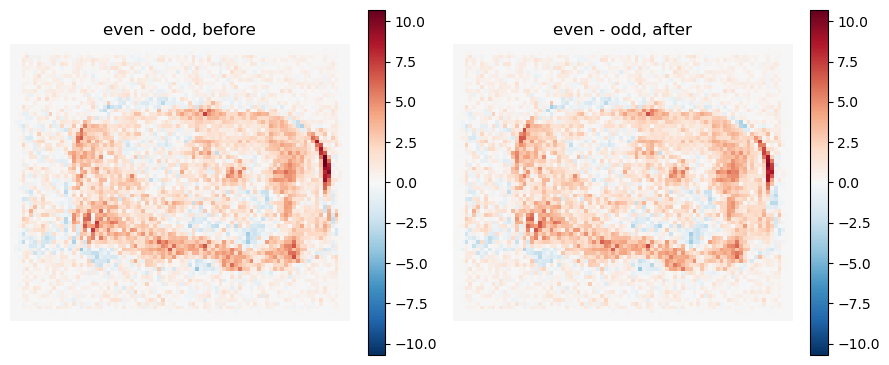

In [44]:
z, ti = MATRIX[2] // 2, SENS_REF_TI
before = np.abs(img['even'][ti][:, :, z]) - np.abs(img['odd'][ti][:, :, z])
after  = np.abs(img['even'][ti][:, :, z]) - np.abs(img_odd_reg[ti][:, :, z])
lim = np.abs(before).max()

fig, ax = plt.subplots(1, 2, figsize=(9, 4.2))
for a, d, t in zip(ax, (before, after), ('before', 'after')):
    im = a.imshow(d, cmap='RdBu_r', vmin=-lim, vmax=lim)
    a.set_title(f'even - odd, {t}'); a.axis('off')
    plt.colorbar(im, ax=a, fraction=0.046)
plt.tight_layout(); plt.show()

## 11. Polarity correction (PSIR) and echo combination

$$S_\mathrm{corr}(TI) = \tfrac{1}{2}\Big[
S_\mathrm{even}(TI)\,e^{-i\angle S_\mathrm{even}(TI_\mathrm{ref})} +
S_\mathrm{odd}(TI)\,e^{-i\angle S_\mathrm{odd}(TI_\mathrm{ref})}\Big]$$

Same caveat as before: this assumes the reference TI is past the null for
everything present, which holds for $T_1 \lesssim 1150$ ms at 800 ms. CSF at
64 mT is still inverted there, so restrict brain quantification to a WM/GM mask
or add a longer TI.

median |Im|/|S| at TI=800 inside object: 0.000


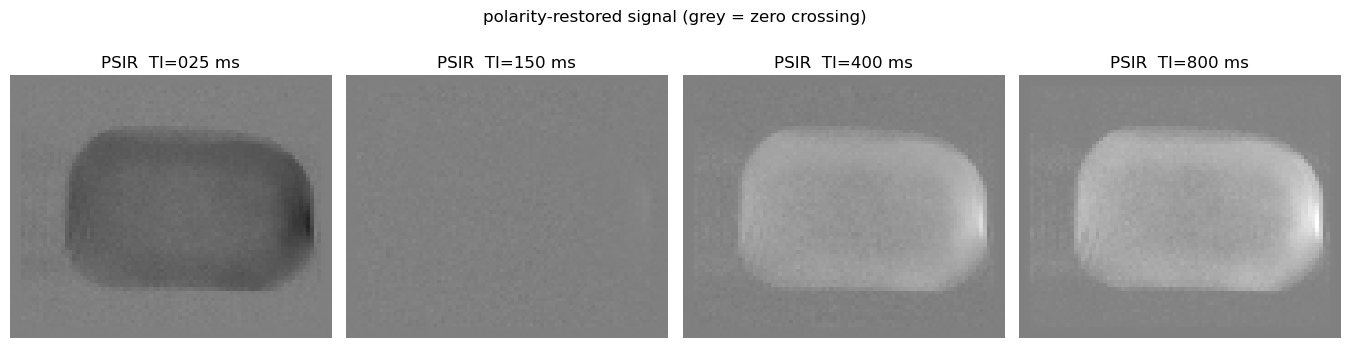

In [45]:
ph_even = np.angle(img['even'][PHASE_REF_TI])
ph_odd  = np.angle(img_odd_reg[PHASE_REF_TI])

corrected, psir = {}, {}
for ti in TI:
    ce = img['even'][ti] * np.exp(-1j * ph_even)
    co = img_odd_reg[ti] * np.exp(-1j * ph_odd)
    corrected[ti] = 0.5 * (ce + co)
    psir[ti] = np.real(corrected[ti]).astype(np.float32)

ref = corrected[PHASE_REF_TI]
inside = np.abs(ref) > 0.2 * np.abs(ref).max()
print(f'median |Im|/|S| at TI={PHASE_REF_TI} inside object: '
      f'{np.median((np.abs(np.imag(ref)) / np.abs(ref))[inside]):.3f}')

z = MATRIX[2] // 2
vmax = np.abs(psir[TI[-1]][:, :, z]).max()
fig, axes = plt.subplots(1, len(TI), figsize=(3.4 * len(TI), 3.8))
for c, ti in enumerate(TI):
    axes[c].imshow(psir[ti][:, :, z], cmap='gray', vmin=-vmax, vmax=vmax)
    axes[c].set_title(f'PSIR  TI={ti} ms'); axes[c].axis('off')
plt.suptitle('polarity-restored signal (grey = zero crossing)')
plt.tight_layout(); plt.show()

## 12. Voxel-wise T1 fit

$$S(TI) = M_0\left(1 - 2e^{-TI/T_1} + e^{-TR/T_1}\right),
\qquad TR = TR_\mathrm{base} + TI$$

$M_0$ enters linearly, so for fixed $T_1$ it has a closed form and the residual
reduces to a function of $T_1$ alone. A dense grid search then finds the global
optimum with no starting guess and no convergence failures, vectorised across
voxels. Unfitted voxels are `NaN`, not `0`.

In [46]:
TI_s = TI_ms / 1000.0
TR_s = TI_s + TR_BASE_S


def ir_signal(T1, ti_s=TI_s, tr_s=TR_s):
    return 1.0 - 2.0 * np.exp(-ti_s / T1) + np.exp(-tr_s / T1)


shape = psir[TI[0]].shape
S = np.stack([psir[ti] for ti in TI], axis=-1).reshape(-1, len(TI)).astype(np.float32)

mag  = np.abs(img['even'][SENS_REF_TI]).ravel()
thr  = MASK_FRAC * np.percentile(mag, 99.5)
mask = mag > thr
print(f'fitting {mask.sum():,} / {mask.size:,} voxels '
      f'({100 * mask.mean():.1f}%), threshold {thr:.4g}')

T1_GRID = np.logspace(*np.log10(T1_RANGE_S), T1_NGRID).astype(np.float32)
F   = np.stack([ir_signal(t) for t in T1_GRID]).astype(np.float32)
den = np.sum(F ** 2, axis=1)

T1map = np.full(S.shape[0], np.nan, np.float32)
M0map = np.full(S.shape[0], np.nan, np.float32)
R2map = np.full(S.shape[0], np.nan, np.float32)

idx = np.flatnonzero(mask)
for chunk in np.array_split(idx, max(1, len(idx) // 8000)):
    s   = S[chunk]
    num = s @ F.T
    rss = (s ** 2).sum(1, keepdims=True) - num ** 2 / den
    k   = np.argmin(rss, axis=1)
    v   = np.arange(len(chunk))
    T1map[chunk] = T1_GRID[k]
    M0map[chunk] = num[v, k] / den[k]
    sst = ((s - s.mean(1, keepdims=True)) ** 2).sum(1)
    R2map[chunk] = 1.0 - rss[v, k] / np.maximum(sst, 1e-12)

if REFINE_FIT:
    def model(x, T1, M0):
        return M0 * (1 - 2 * np.exp(-x[0] / T1) + np.exp(-x[1] / T1))
    xd = (TI_s, TR_s)
    for j in idx:
        try:
            p, _ = curve_fit(model, xd, S[j], p0=[T1map[j], M0map[j]],
                             bounds=([T1_RANGE_S[0], -np.inf],
                                     [T1_RANGE_S[1],  np.inf]), maxfev=400)
            T1map[j], M0map[j] = p
        except Exception:
            pass

T1map = T1map.reshape(shape)
M0map = M0map.reshape(shape)
R2map = R2map.reshape(shape)
railed = np.nanmean((T1map <= T1_RANGE_S[0] * 1.01) | (T1map >= T1_RANGE_S[1] * 0.99))
print(f'done.  median R^2 = {np.nanmedian(R2map):.3f},  '
      f'{100 * railed:.2f}% of fitted voxels at a grid edge')

fitting 108,383 / 253,440 voxels (42.8%), threshold 1.363
done.  median R^2 = 0.996,  0.78% of fitted voxels at a grid edge


## 13. Inspect

Treat R² as a coarse flag, not a test: with four inversion times and two free
parameters there are only two degrees of freedom, so it stays above 0.99 even
when noise has moved T1 by 10–15%. It is useful for spotting *systematically*
bad regions — failed polarity restoration, motion between the echoes, a
sensitivity map that doesn't fit the data — not for grading single voxels.

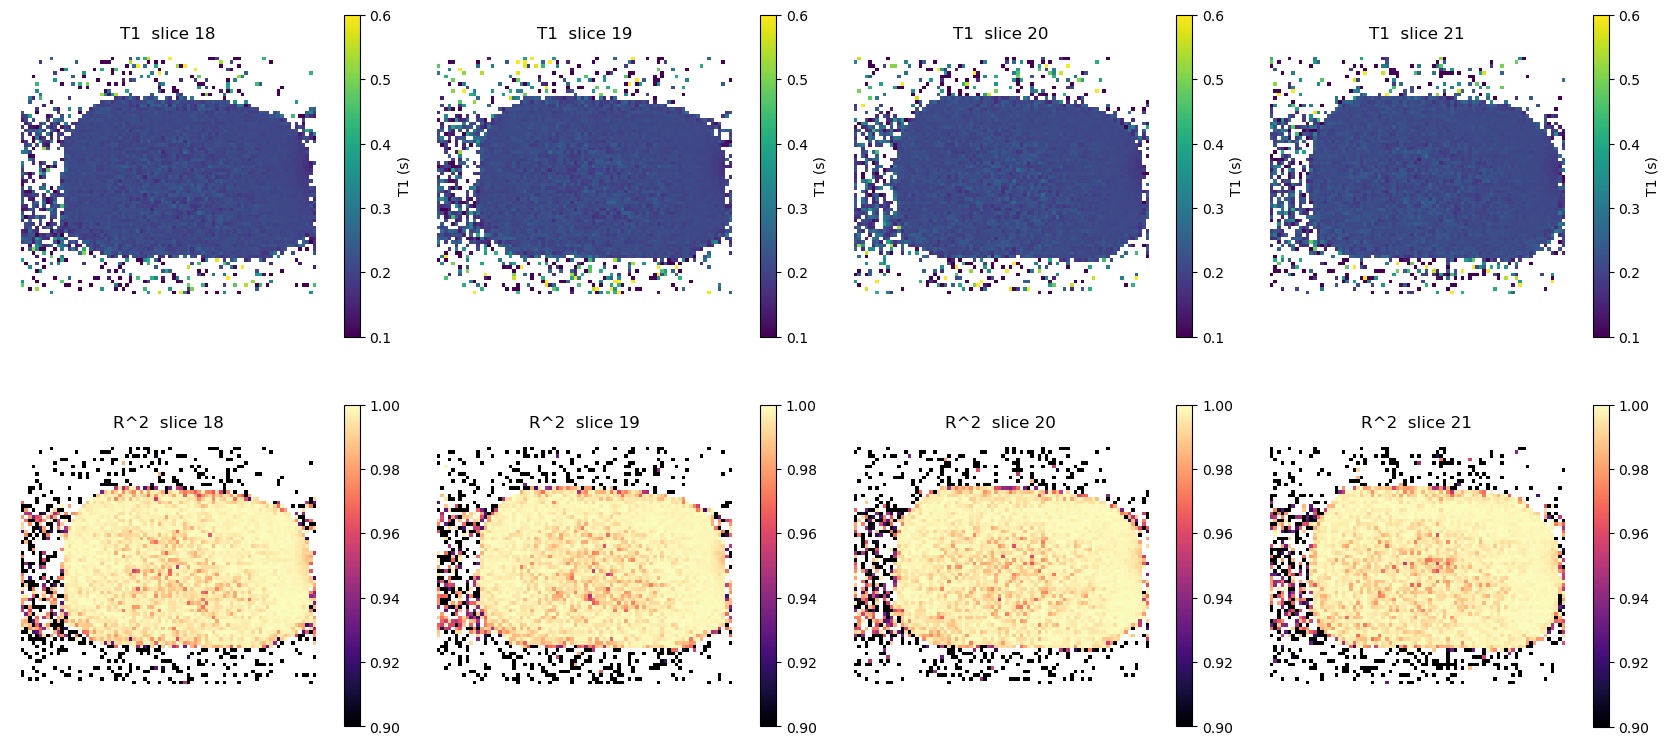

In [47]:
T1_VMIN, T1_VMAX = 0.10, 0.60      # s - adjust to your phantom

slices = range(max(0, MATRIX[2] // 2 - 2), min(MATRIX[2], MATRIX[2] // 2 + 2))
fig, axes = plt.subplots(2, len(slices), figsize=(4.2 * len(slices), 8))
axes = np.atleast_2d(axes)
for c, z in enumerate(slices):
    im0 = axes[0, c].imshow(T1map[:, :, z], cmap='viridis',
                            vmin=T1_VMIN, vmax=T1_VMAX)
    axes[0, c].set_title(f'T1  slice {z}'); axes[0, c].axis('off')
    plt.colorbar(im0, ax=axes[0, c], fraction=0.046, label='T1 (s)')

    im1 = axes[1, c].imshow(R2map[:, :, z], cmap='magma', vmin=0.9, vmax=1.0)
    axes[1, c].set_title(f'R^2  slice {z}'); axes[1, c].axis('off')
    plt.colorbar(im1, ax=axes[1, c], fraction=0.046)
plt.tight_layout(); plt.show()

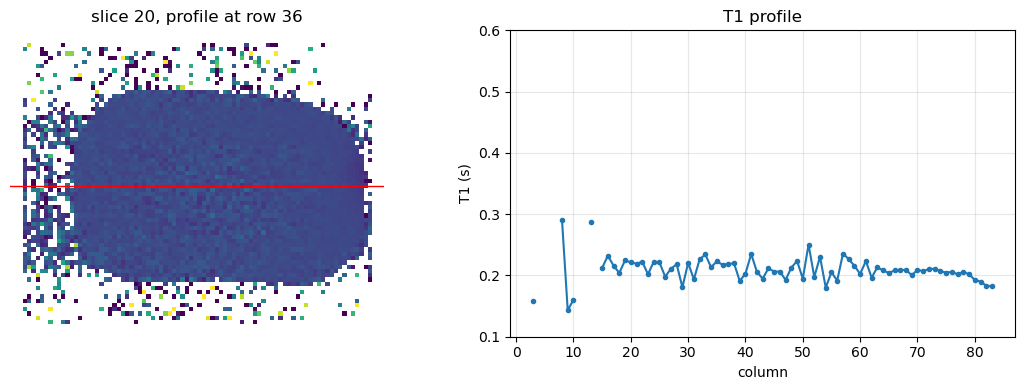

In [48]:
# Line profile through the T1 map - the honest test for small inserts.
z_prof, row = MATRIX[2] // 2, MATRIX[0] // 2

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].imshow(T1map[:, :, z_prof], cmap='viridis', vmin=T1_VMIN, vmax=T1_VMAX)
ax[0].axhline(row, color='r', lw=1)
ax[0].set_title(f'slice {z_prof}, profile at row {row}'); ax[0].axis('off')

ax[1].plot(T1map[row, :, z_prof], '-o', ms=3)
ax[1].set_xlabel('column'); ax[1].set_ylabel('T1 (s)')
ax[1].set_ylim(T1_VMIN, T1_VMAX); ax[1].grid(alpha=0.3)
ax[1].set_title('T1 profile')
plt.tight_layout(); plt.show()

In [49]:
# ROI statistics. (label, x, y, z) centres; a cube of side `win` is averaged
# with outliers beyond `nsig` sigma dropped.
ROIS = [
    # ('vial 1', 43, 35, 15),
    # ('WM mimic', 30, 50, 15),
]
win, nsig = 3, 2.0
r = win // 2

for label, x, y, z in ROIS:
    box = T1map[max(0, x - r):x + r + 1,
                max(0, y - r):y + r + 1,
                max(0, z - r):z + r + 1].ravel()
    box = box[np.isfinite(box)]
    if box.size == 0:
        print(f'{label:>12s}: no fitted voxels'); continue
    keep = box[np.abs(box - box.mean()) < nsig * box.std()] if box.std() > 0 else box
    print(f'{label:>12s} ({x},{y},{z}): T1 = {keep.mean() * 1000:6.1f} '
          f'+/- {1000 * keep.std() / np.sqrt(keep.size):4.1f} ms   '
          f'(n = {keep.size})')

## 14. Export

Orientation flips go in the affine, not in the array — `np.flip` on the data
with an unchanged affine silently changes the orientation NIfTI reports.

In [50]:
OUT_DIR.mkdir(parents=True, exist_ok=True)

SX, SY, SZ = -1.0, -1.0, 1.0
affine = np.diag([SX * RES_MM[0], SY * RES_MM[1], SZ * RES_MM[2], 1.0])

stem = f'{date}_{patient}_{US_VER}_LLR{LLR_LAMBDA}_i{LLR_ITER}_{SENS_SOURCE}'
for name, vol in (('T1map_s', T1map), ('M0map', M0map), ('R2map', R2map)):
    p = OUT_DIR / f'{name}_{stem}.nii.gz'
    nib.save(nib.Nifti1Image(np.nan_to_num(vol, nan=0.0).astype(np.float32), affine), p)
    print('wrote', p)

ref = np.abs(img['even'][SENS_REF_TI]).astype(np.float32)
p = OUT_DIR / f'IR{SENS_REF_TI}_mag_{stem}.nii.gz'
nib.save(nib.Nifti1Image(ref, affine), p)
print('wrote', p)

wrote T1_map_data/20260706/T1map_s_20260706_Gummy_US4_US_4_LLR0.005_i40_t2_native.nii.gz
wrote T1_map_data/20260706/M0map_20260706_Gummy_US4_US_4_LLR0.005_i40_t2_native.nii.gz
wrote T1_map_data/20260706/R2map_20260706_Gummy_US4_US_4_LLR0.005_i40_t2_native.nii.gz
wrote T1_map_data/20260706/IR800_mag_20260706_Gummy_US4_US_4_LLR0.005_i40_t2_native.nii.gz


### Masking, as before

```bash
conda activate hdbet_env
hd-bet -i IR800_mag_<stem>.nii.gz -o brain.nii.gz -device mps --save_bet_mask
fslmaths T1map_s_<stem>.nii.gz -mas brain_bet.nii.gz T1map_masked.nii.gz
```

Unfitted voxels are `NaN` in memory but written as `0`, so mask before any FSL
statistic or the zeros will drag the mean down.

### Suggested comparison, now that you have both

The filename carries `SENS_SOURCE` and `LLR_LAMBDA`, so you can build a small
matrix of runs and load them together in FSLeyes:

1. `SENS_SOURCE = 't2_native'` vs `'t2_legacy'` at fixed lambda — isolates the
   coil-map geometry question. Same T1 numbers means it never mattered.
2. `LLR_LAMBDA` sweep at fixed `SENS_SOURCE` — isolates the regulariser.
3. Both against the fully sampled T1 map, which has no regulariser at all and
   is the reference for what the inserts should read.

That third comparison is the one that settles whether LLR is responsible for
the missing structures, and it is now a like-for-like comparison because both
notebooks share the same fit, the same PSIR step and the same masking.